In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('../data/placement.csv')
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


<Axes: xlabel='cgpa', ylabel='resume_score'>

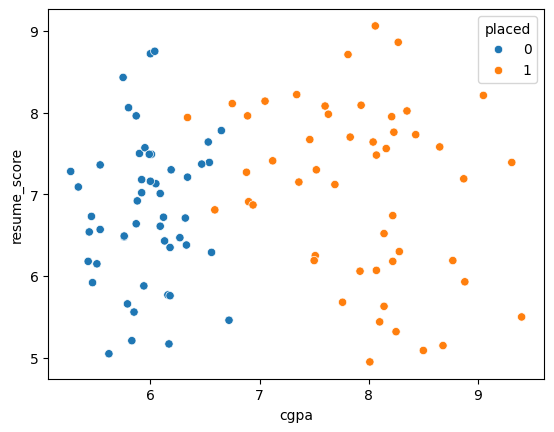

In [29]:
sns.scatterplot(x='cgpa', y='resume_score', data=df, hue='placed')

In [30]:
X = df[['cgpa', 'resume_score']].to_numpy()
X

array([[8.14, 6.52],
       [6.17, 5.17],
       [8.27, 8.86],
       [6.88, 7.27],
       [7.52, 7.3 ],
       [8.77, 6.19],
       [5.34, 7.09],
       [6.56, 6.29],
       [6.32, 6.71],
       [7.69, 7.12],
       [6.18, 6.35],
       [5.44, 6.54],
       [6.09, 7.01],
       [8.5 , 5.09],
       [7.51, 6.25],
       [8.88, 5.93],
       [8.04, 7.64],
       [7.81, 8.71],
       [5.94, 5.88],
       [6.75, 8.11],
       [5.8 , 8.06],
       [6.53, 7.64],
       [6.16, 5.77],
       [6.05, 7.13],
       [8.22, 6.18],
       [7.76, 5.68],
       [6.27, 6.47],
       [5.51, 6.15],
       [7.46, 7.67],
       [6.19, 7.3 ],
       [7.36, 7.15],
       [5.92, 7.02],
       [5.87, 7.96],
       [8.43, 7.73],
       [8.87, 7.19],
       [8.07, 7.48],
       [8.16, 7.56],
       [9.05, 8.21],
       [6.  , 8.72],
       [7.5 , 6.19],
       [8.25, 5.32],
       [8.68, 5.15],
       [6.9 , 6.91],
       [8.21, 7.95],
       [5.47, 5.92],
       [8.1 , 5.44],
       [5.83, 5.21],
       [7.05,

In [31]:
y = df['placed'].to_numpy()
y

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0])

In [32]:
def step(z):
    return 1 if z >= 0 else 0

In [42]:
def perceptron(X, y, epochs=10000, lr=0.1):

    # Add bias term
    X = np.insert(X, 0, 1, axis=1)

    # Initialize weights
    w = np.ones(X.shape[1])

    for _ in range(epochs):

        # Select random sample
        idx = np.random.randint(0, X.shape[0])

        xi = X[idx]
        yi = y[idx]

        # Linear combination
        z = np.dot(w, xi)

        # Prediction
        y_hat = step(z)

        # Weight update
        w = w + lr * (yi - y_hat) * xi

    return w

In [43]:
w = perceptron(X, y)
w

array([-23.3  ,   5.041,  -1.609])

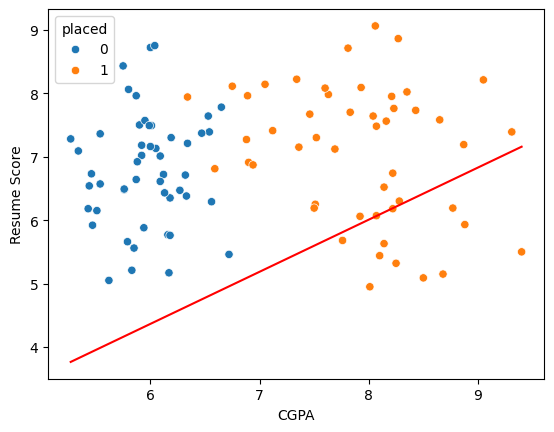

In [41]:
# Scatter plot
sns.scatterplot(
    x=df['cgpa'],
    y=df['resume_score'],
    hue=df['placed']
)

# Create x values
x1 = np.linspace(X[:,0].min(), X[:,0].max(), 100)

# Compute line
x2 = -(w[0] + w[1] * x1) / w[2]

# Plot decision boundary
plt.plot(x1, x2, color='red')

plt.xlabel("CGPA")
plt.ylabel("Resume Score")

plt.show()

Weights: [-2.7    4.444 -4.083]


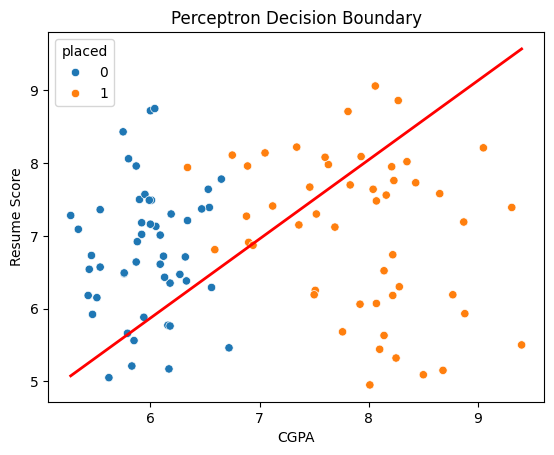

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/placement.csv')

# Features and target
X = df[['cgpa', 'resume_score']].to_numpy()
y = df['placed'].to_numpy()


# Step function
def step(z):
    return 1 if z >= 0 else 0


# Perceptron
def perceptron(X, y, epochs=1000, lr=0.1):

    # Add bias column
    X = np.insert(X, 0, 1, axis=1)

    # Initialize weights
    w = np.ones(X.shape[1])

    for _ in range(epochs):

        # Random sample
        idx = np.random.randint(0, X.shape[0])

        xi = X[idx]
        yi = y[idx]

        # Prediction
        z = np.dot(w, xi)
        y_hat = step(z)

        # Weight update
        w = w + lr * (yi - y_hat) * xi

    return w


# Train model
w = perceptron(X, y)

print("Weights:", w)


# -----------------------------
# Visualization
# -----------------------------

# Scatter plot
sns.scatterplot(
    x=df['cgpa'],
    y=df['resume_score'],
    hue=df['placed']
)

# Decision boundary
# w0 + w1*x1 + w2*x2 = 0
#
# x2 = -(w0 + w1*x1) / w2

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

x2 = -(w[0] + w[1] * x1) / w[2]

# Plot line
plt.plot(x1, x2, color='red', linewidth=2)

plt.xlabel("CGPA")
plt.ylabel("Resume Score")

plt.title("Perceptron Decision Boundary")

plt.show()